# Day 1 — Python for AI Warm-Up

Author: niyonkuru_222006682@stud.ur.ac.rw

This notebook demonstrates Python fundamentals, three utility functions, NumPy/Pandas basics, and one chart, as required by the Day 1 assignment.

## Task 1 — Environment Proof: Smoke Test

In [1]:
import numpy, pandas, sklearn, matplotlib
print("all good")

all good


## Task 2 — Python Fundamentals

### Five data types

In [2]:
model_name = "logistic-regression"   # str: text label for the model
epoch_count = 12                     # int: whole number of training passes
accuracy = 0.9345                    # float: fractional accuracy score
is_ready = True                      # bool: flag for whether we can ship
extra_notes = None                   # NoneType: placeholder, nothing recorded yet

for value in (model_name, epoch_count, accuracy, is_ready, extra_notes):
    print(value, "->", type(value))

logistic-regression -> <class 'str'>
12 -> <class 'int'>
0.9345 -> <class 'float'>
True -> <class 'bool'>
None -> <class 'NoneType'>


### Casting

In [3]:
score_text = "87.6"
score_float = float(score_text)      # string -> float: parses the numeral, keeps the decimal
score_int = int(score_float)         # float -> int: truncates toward zero, decimal part is dropped (87.6 -> 87, not rounded)
print(score_text, "->", score_float, "->", score_int)

87.6 -> 87.6 -> 87


### f-string report

In [4]:
report_model = "random-forest"
report_accuracy = 0.9187
report_epochs = 20

print(f"Model {report_model} reached {report_accuracy:.1%} accuracy after {report_epochs} epochs.")

Model random-forest reached 91.9% accuracy after 20 epochs.


### Conditional: ship it / too slow / keep training

In [5]:
def decide(accuracy_value, latency_ms):
    if accuracy_value >= 0.90 and latency_ms <= 100:
        return "ship it"
    elif latency_ms > 100:
        return "too slow"
    else:
        return "keep training"

for acc, lat in [(0.95, 80), (0.95, 150), (0.70, 60)]:
    print(f"accuracy={acc}, latency={lat}ms -> {decide(acc, lat)}")

accuracy=0.95, latency=80ms -> ship it
accuracy=0.95, latency=150ms -> too slow
accuracy=0.7, latency=60ms -> keep training


### Loop with enumerate()

In [6]:
scores = [0.62, 0.74, 0.81, 0.88, 0.90]
for epoch, score in enumerate(scores):
    print(f"epoch {epoch}: {score}")

epoch 0: 0.62
epoch 1: 0.74
epoch 2: 0.81
epoch 3: 0.88
epoch 4: 0.9


### Four collections

In [7]:
epoch_scores = [0.62, 0.74, 0.81, 0.88, 0.90]   # list: ordered, mutable — scores accumulate in training order
image_shape = (224, 224, 3)                      # tuple: fixed-size, immutable — a shape shouldn't change by accident
hyperparams = {"lr": 0.001, "batch_size": 32}    # dict: named fields — look up a hyperparameter by name
seen_labels = {"cat", "dog", "cat", "bird"}      # set: automatically dedupes — we only care about unique labels

print("list:", epoch_scores)
print("tuple:", image_shape)
print("dict:", hyperparams)
print("set:", seen_labels)

list: [0.62, 0.74, 0.81, 0.88, 0.9]
tuple: (224, 224, 3)
dict: {'lr': 0.001, 'batch_size': 32}
set: {'dog', 'bird', 'cat'}


### Two comprehensions

In [8]:
good_scores = [s for s in epoch_scores if s >= 0.8]        # list comprehension with a filter
score_by_epoch = {i: s for i, s in enumerate(epoch_scores)}  # dict comprehension

print("good_scores:", good_scores)
print("score_by_epoch:", score_by_epoch)

good_scores: [0.81, 0.88, 0.9]
score_by_epoch: {0: 0.62, 1: 0.74, 2: 0.81, 3: 0.88, 4: 0.9}


## Task 3 — Three Functions

Implemented in [`src/utils.py`](../src/utils.py) and imported here.

In [9]:
import sys
sys.path.append("../src")
from utils import normalise, summarise_scores, safe_divide, train

### 3.1 normalise()

In [10]:
print(normalise([12, 18, 25, 40]))     # normal case: scales to 0-1 range
print(normalise([5, 5, 5, 5]))         # identical values: returns zeros instead of dividing by zero

[0.0, 0.21428571428571427, 0.4642857142857143, 1.0]
[0.0, 0.0, 0.0, 0.0]


### 3.2 summarise_scores()

In [11]:
print(summarise_scores([0.62, 0.74, 0.81, 0.88, 0.90]))  # normal case
print(summarise_scores([]))                                # empty list: count/above_threshold are 0, stats are None

{'count': 5, 'mean': 0.79, 'minimum': 0.62, 'maximum': 0.9, 'above_threshold': 3}
{'count': 0, 'mean': None, 'minimum': None, 'maximum': None, 'above_threshold': 0}


### 3.3 safe_divide()

In [12]:
print(safe_divide(10, 2))          # normal case -> 5.0
print(safe_divide(10, 0))          # divide-by-zero -> default 0.0
print(safe_divide(10, "oops"))     # non-numeric input -> default 0.0

5.0
0.0
0.0


### Stretch: *args / **kwargs

In [13]:
train("resnet50", epochs=10, learning_rate=0.001)

positional args: ('resnet50',)
keyword args: {'epochs': 10, 'learning_rate': 0.001}


## Task 4 — NumPy and Pandas

### NumPy

In [14]:
import numpy as np

arr_1d = np.array([12, 18, 25, 40, 31, 22])
print("mean:", arr_1d.mean())
print("std:", arr_1d.std())
print("min:", arr_1d.min())
print("max:", arr_1d.max())

mean: 24.666666666666668
std: 9.01233722306385
min: 12
max: 40


In [15]:
arr_2d = np.arange(12).reshape(3, 4)
print("shape:", arr_2d.shape)
print("transpose shape:", arr_2d.T.shape)

shape: (3, 4)
transpose shape: (4, 3)


In [16]:
col_means = arr_2d.mean(axis=0)
centered = arr_2d - col_means   # broadcasting: subtracts each column's mean from every row
print(centered)

[[-4. -4. -4. -4.]
 [ 0.  0.  0.  0.]
 [ 4.  4.  4.  4.]]


### Pandas

In [17]:
import pandas as pd

df = pd.DataFrame({
    "model": ["log-reg", "random-forest", "svm", "knn", "xgboost", "mlp"],
    "accuracy": [0.81, 0.88, 0.79, None, 0.92, 0.85],
    "latency_ms": [12, 45, 30, 8, 60, 25],
    "epochs": [5, 20, 5, 1, 30, 15],
})
df

,model,accuracy,latency_ms,epochs
0,log-reg,0.81,12,5
1,random-forest,0.88,45,20
2,svm,0.79,30,5
3,knn,NaN,8,1
4,xgboost,0.92,60,30
5,mlp,0.85,25,15


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model       6 non-null      object 
 1   accuracy    5 non-null      float64
 2   latency_ms  6 non-null      int64  
 3   epochs      6 non-null      int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 324.0+ bytes


In [19]:
df.describe()

,accuracy,latency_ms,epochs
count,5.00000,6.000000,6.000000
mean,0.85000,30.000000,12.666667
std,0.05244,19.788886,11.075498
min,0.79000,8.000000,1.000000
25%,0.81000,15.250000,5.000000
50%,0.85000,27.500000,10.000000
75%,0.88000,41.250000,18.750000
max,0.92000,60.000000,30.000000


In [20]:
df.isna().sum()

model         0
accuracy      1
latency_ms    0
epochs        0
dtype: int64

In [21]:
fast_models = df[df["latency_ms"] < 40].sort_values("accuracy", ascending=False)
fast_models

,model,accuracy,latency_ms,epochs
5,mlp,0.85,25,15
0,log-reg,0.81,12,5
2,svm,0.79,30,5
3,knn,NaN,8,1


In [22]:
df["pass"] = df["accuracy"] >= 0.8   # derived column: boolean pass/fail flag
df

,model,accuracy,latency_ms,epochs,pass
0,log-reg,0.81,12,5,True
1,random-forest,0.88,45,20,True
2,svm,0.79,30,5,False
3,knn,NaN,8,1,False
4,xgboost,0.92,60,30,True
5,mlp,0.85,25,15,True


If this were real data, the missing accuracy value for `knn` would mean that model's evaluation run either failed to log a result or was never scored, so we cannot yet say whether it passes or fails. Leaving it as `NaN` rather than guessing a value keeps that gap visible instead of silently biasing later averages or the pass/fail count.

## Task 5 — One Chart, One Claim

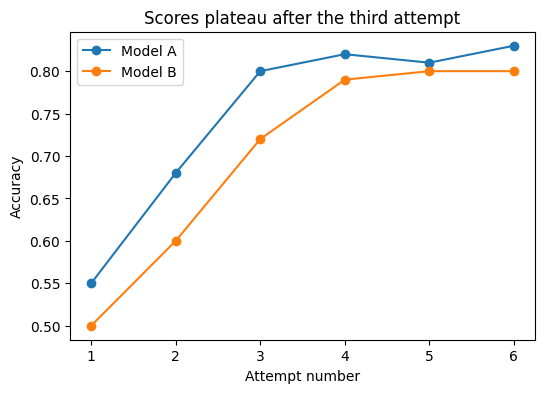

In [23]:
import matplotlib.pyplot as plt
import os

attempts = [1, 2, 3, 4, 5, 6]
scores_a = [0.55, 0.68, 0.80, 0.82, 0.81, 0.83]
scores_b = [0.50, 0.60, 0.72, 0.79, 0.80, 0.80]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(attempts, scores_a, marker="o", label="Model A")
ax.plot(attempts, scores_b, marker="o", label="Model B")
ax.set_xlabel("Attempt number")
ax.set_ylabel("Accuracy")
ax.set_title("Scores plateau after the third attempt")
ax.legend()

os.makedirs("../reports", exist_ok=True)
fig.savefig("../reports/day01_chart.png", dpi=150, bbox_inches="tight")
plt.show()